In [1]:
import pandas as pd
import os

# 1. 读取原始数据
# 请确保 'regional_economy.csv' 在您的当前脚本目录下
try:
    data_raw = pd.read_csv('regional_economy.csv')
except FileNotFoundError:
    print("❌ 错误：找不到文件 'regional_economy.csv'。请检查文件是否在当前目录下。")
    exit()

# 2. 【关键】使用你的学号后四位作为随机种子，抽取25个样本
student_id_last4 = 420  # <--- 请确保这里是你修改后的学号后四位，数字前不能加0，如学号后四位为0188，此处改写为188
df = data_raw.sample(n=25, random_state=student_id_last4)

print(f"✅ 我的专属分析数据已生成，共 {len(df)} 行。")

# 3. 【新增步骤】将数据保存到本地
# 定义保存的文件名，建议加上学号以便区分
output_filename = f'regional_economy_{student_id_last4}.csv'

# index=False: 不把 pandas 的索引列（0, 1, 2...）保存进去，保持数据整洁
# encoding='utf-8-sig': 这是一个关键参数，防止用 Excel 打开时中文出现乱码
df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"💾 数据已成功保存至本地文件：{output_filename}")
print("   (您现在可以在文件夹中找到并打开这个文件了)")

✅ 我的专属分析数据已生成，共 25 行。
💾 数据已成功保存至本地文件：regional_economy_420.csv
   (您现在可以在文件夹中找到并打开这个文件了)


### 一、经典线性回归与诊断

In [ ]:
# =========================
# 1. 导入所需的库
# =========================

import pandas as pd
import numpy as np

# 回归分析相关
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_white

# 可视化（用于残差图）
import matplotlib.pyplot as plt
# 中文显示支持
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# =========================
# 2. 读取数据
# =========================
# 读取 CSV 数据
data = pd.read_csv('regional_economy_420.csv')

# =========================
# 3. 构造自变量和因变量
# =========================

# 因变量
Y = data['Y']

# 自变量（X1 - X6）
X = data[['X1', 'X2', 'X3', 'X4', 'X5', 'X6']]

# 加入常数项（截距）
X = sm.add_constant(X)

# =========================
# 4. 建立 OLS 回归模型
# =========================

model = sm.OLS(Y, X)
results = model.fit()

# 输出回归结果
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     20.25
Date:                Tue, 23 Dec 2025   Prob (F-statistic):           4.26e-07
Time:                        16:42:21   Log-Likelihood:                -95.192
No. Observations:                  25   AIC:                             204.4
Df Residuals:                      18   BIC:                             212.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -31.8156     14.515     -2.192      0.0

In [3]:
# =========================
# 5. 计算 VIF
# =========================

# 创建一个 DataFrame 保存 VIF 结果
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns

# 计算每个变量的 VIF
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Variable,VIF
0,const,31.919441
1,X1,138.779493
2,X2,85.403188
3,X3,24.316002
4,X4,1.054633
5,X5,5.133908
6,X6,5.104518


In [4]:
# =========================
# 6. White 异方差检验
# =========================

# 获取残差
residuals = results.resid

# White 检验
white_test = het_white(residuals, X)

# White 检验结果
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
white_test_results = dict(zip(labels, white_test))

white_test_results

{'LM Statistic': 25.0,
 'LM-Test p-value': 0.4057606888114827,
 'F-Statistic': nan,
 'F-Test p-value': nan}

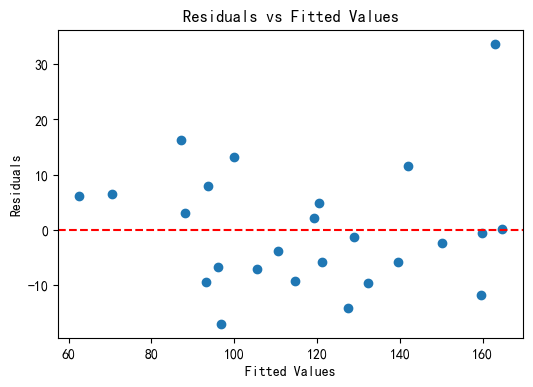

In [10]:
# =========================
#  绘制残差图
# =========================

# 拟合值
fitted_values = results.fittedvalues

plt.figure(figsize=(6, 4))
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')

plt.show()


## 逐步回归

In [5]:

import pandas as pd
import numpy as np
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

# -------------------------
# 1. 读取数据
# -------------------------
data = pd.read_csv('regional_economy_420.csv')

# 检查列名（确保包含 Y, X1..X6）
print("Columns:", list(data.columns))
data.head()

Columns: ['Region', 'Y', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6']


,Region,Y,X1,X2,X3,X4,X5,X6
0,省份10,91.14,14826.09,9734.94,1480.98,66.34,1.28,50.0
1,省份08,101.52,13336.60,10471.50,1616.56,50.84,4.12,91.0
2,省份27,113.27,38644.44,26487.16,6044.29,73.50,1.19,10.0
3,省份30,196.61,48127.10,34517.72,7717.08,91.95,0.91,15.0
4,省份02,68.73,3146.62,877.79,935.52,49.53,2.14,59.0


In [6]:
def fit_ols(df, y_col, x_cols):
    """
    df: 数据
    y_col: 因变量列名
    x_cols: 自变量列名列表
    """
    y = df[y_col]
    X = df[x_cols].copy()
    X = sm.add_constant(X)  # 加截距项
    model = sm.OLS(y, X).fit()
    return model

# 定义：双向逐步回归
def stepwise_selection_aic(df, y_col, candidate_x_cols, verbose=True):
    """
    双向逐步回归（forward + backward），以 AIC 作为准则：
    - forward: 尝试加入一个变量，看 AIC 是否下降
    - backward: 在已选变量中尝试删去一个变量，看 AIC 是否下降
    最终返回：入选变量列表、最终模型
    """
    included = []  # 当前入选变量
    best_aic = np.inf
    changed = True

    while changed:
        changed = False

        # ---------- Forward step ----------
        excluded = list(set(candidate_x_cols) - set(included))
        forward_aic = []
        for col in excluded:
            trial_cols = included + [col]
            model = fit_ols(df, y_col, trial_cols)
            forward_aic.append((model.aic, col))

        if forward_aic:
            forward_aic.sort()
            new_aic, best_new_col = forward_aic[0]
            if new_aic + 1e-8 < best_aic:  # AIC 更小则接受
                included.append(best_new_col)
                best_aic = new_aic
                changed = True
                if verbose:
                    print(f"[Forward] Add {best_new_col:>3}  => AIC = {best_aic:.4f}")

        # ---------- Backward step ----------
        # 在当前 included 中，尝试删去一个变量，看 AIC 是否下降
        if included:
            backward_aic = []
            for col in included:
                trial_cols = [c for c in included if c != col]
                if len(trial_cols) == 0:
                    continue
                model = fit_ols(df, y_col, trial_cols)
                backward_aic.append((model.aic, col))

            if backward_aic:
                backward_aic.sort()
                new_aic, worst_col = backward_aic[0]
                if new_aic + 1e-8 < best_aic:
                    included.remove(worst_col)
                    best_aic = new_aic
                    changed = True
                    if verbose:
                        print(f"[Backward] Drop {worst_col:>3} => AIC = {best_aic:.4f}")

    final_model = fit_ols(df, y_col, included) if included else None
    return included, final_model


In [11]:
# 执行逐步回归
y_col = 'Y'
candidate_x_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

selected_vars, final_model = stepwise_selection_aic(
    data, y_col, candidate_x_cols, verbose=True
)

print("\n最终入选变量：", selected_vars)
#  输出“最终模型方程”
params = final_model.params  # 回归系数（包含 const）
print("\n最终模型方程（估计值）：")

# 组装方程字符串
equation = f"Y = {params['const']:.6f}"
for v in selected_vars:
    equation += f" + ({params[v]:.6f})*{v}"
print(equation)

print("\n最终模型摘要：")
print(final_model.summary())

[Forward] Add  X4  => AIC = 221.4747
[Forward] Add  X1  => AIC = 209.1304
[Forward] Add  X5  => AIC = 199.0699

最终入选变量： ['X4', 'X1', 'X5']

最终模型方程（估计值）：
Y = -31.176384 + (1.495326)*X4 + (0.000988)*X1 + (8.345551)*X5

最终模型摘要：
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     45.79
Date:                Tue, 23 Dec 2025   Prob (F-statistic):           2.17e-09
Time:                        17:08:10   Log-Likelihood:                -95.535
No. Observations:                  25   AIC:                             199.1
Df Residuals:                      21   BIC:                             203.9
Df Model:                           3                                         
Covariance Type:            nonrobust                           

In [8]:
#  输出“最终模型方程”
params = final_model.params  # 回归系数（包含 const）
print("\n最终模型方程（估计值）：")

# 组装方程字符串
equation = f"Y = {params['const']:.6f}"
for v in selected_vars:
    equation += f" + ({params[v]:.6f})*{v}"
print(equation)



最终模型方程（估计值）：
Y = -31.176384 + (1.495326)*X4 + (0.000988)*X1 + (8.345551)*X5
